In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags as sparMtrx

In [25]:
N = 10
xf = 2*np.pi



# x = np.arange(0,N*h,h)
x = np.linspace(0,xf, N)
h = np.diff(x)[0]

In [62]:
left = np.zeros(x.size)
left[:3] = np.array([-3,4,-1])/(2*h)
left


row2 = np.zeros((x.size))
row2[1:4] = np.array([-3,4,-1])/(2*h)


# diag = np.array([-3,4,-2])/(2*h)

# left = sparMtrx(diag,
#               [-1, 0, 1],
#               shape=(3, 3)).toarray()
left

array([-2.14859173,  2.86478898, -0.71619724,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [63]:
row2

array([ 0.        , -2.14859173,  2.86478898, -0.71619724,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [57]:
right = np.zeros(x.size)
right[-3:] = np.array([1,-4,3])/(2*h)
right


bkr2 = np.zeros((x.size))


bkr2[-4:-1] = np.array([1,-4,3])/(2*h)


# diag = np.array([1,-4,3])/(2*h)

# right = sparMtrx(diag,
#               [-1, 0, 1],
#               shape=(3, 3)).toarray()
right
bkr2

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.71619724, -2.86478898,  2.14859173,  0.        ])

In [58]:
diag = np.array([-1,1])/(2*h)

D2 = sparMtrx(diag,
              [-1, 1],
              shape=(x.size, x.size)).toarray()

# D2[:3,:3] = left
# D2[-3:,-3:] = right

D2[0] = left
D2[-1] = right

np.round(D2[:4,:4],2)
# D2[:,-1]

array([[-2.15,  2.86, -0.72,  0.  ],
       [-0.72,  0.  ,  0.72,  0.  ],
       [ 0.  , -0.72,  0.  ,  0.72],
       [ 0.  ,  0.  , -0.72,  0.  ]])

In [59]:
diag = np.array([1,-8,8,-1])/(12*h)

D4 = sparMtrx(diag,
              [-2, -1,  1, 2],
              shape=(x.size, x.size)).toarray()




D4[0] = left
D4[1] = row2
D4[-2] = bkr2
D4[-1] = right


# D4[0] = left
# D4[1,1:4] = left[:3]
# D4[-2,-4:-1] = right[-3:]
# D4[-1] = right

D4[:4,:4]

array([[-2.14859173,  2.86478898, -0.71619724,  0.        ],
       [ 0.        , -2.14859173,  2.86478898, -0.71619724],
       [ 0.11936621, -0.95492966,  0.        ,  0.95492966],
       [ 0.        ,  0.11936621, -0.95492966,  0.        ]])

In [44]:
D4[1]

array([-0.95492966, -2.14859173,  2.86478898, -0.71619724,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [46]:
D4[-1]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.71619724, -2.86478898,  2.14859173])

In [36]:
left[:3]

array([-2.14859173,  2.86478898, -0.71619724])

In [37]:
left

array([-2.14859173,  2.86478898, -0.71619724,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [38]:
right

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.71619724, -2.86478898,  2.14859173])

In [42]:
right[-3:]

array([ 0.71619724, -2.86478898,  2.14859173])

In [60]:
y = np.sin(x)
dy_exact = np.cos(x)

dy_o2 = D2@y
dy_o4 = D4@y

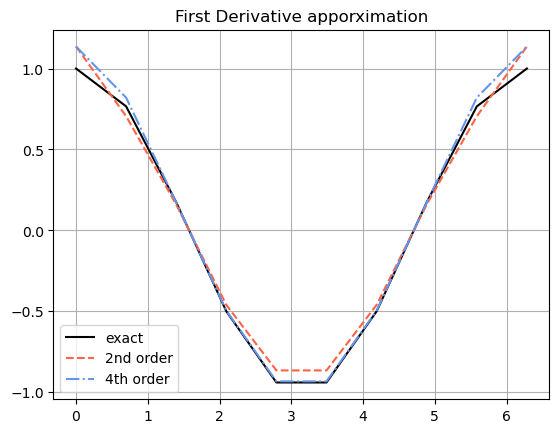

In [61]:
plt.plot(x,dy_exact,color='black',label='exact')
plt.plot(x,dy_o2,color='tomato',linestyle='--',label='2nd order')
plt.plot(x,dy_o4,color='cornflowerblue',linestyle='-.',label='4th order')

plt.grid()

plt.legend()
plt.title('First Derivative apporximation')
plt.show()

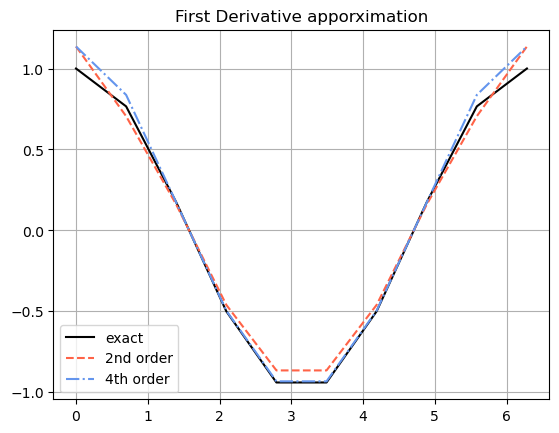

In [34]:
plt.plot(x,dy_exact,color='black',label='exact')
plt.plot(x,dy_o2,color='tomato',linestyle='--',label='2nd order')
plt.plot(x,dy_o4,color='cornflowerblue',linestyle='-.',label='4th order')

plt.grid()

plt.legend()
plt.title('First Derivative apporximation')
plt.show()

In [7]:
# diag = np.array([1,-2,1])/(h**2)

# L2 = sparMtrx(diag,
#               [-1, 0, 1],
#               shape=(x.size, x.size)).toarray()

# L2[:3,:3] = left
# L2[-3:,-3:] = right


# np.round(L2[:4,:4],2)

ValueError: could not broadcast input array from shape (10,) into shape (3,3)

In [ ]:
# diag = np.array([-1,16,-30,16,-1])/(12*h**2)

# L4 = sparMtrx(diag,
#               [-2, -1, 0, 1, 2],
#               shape=(x.size, x.size)).toarray()

# L4[:3,:3] = left
# L4[-3:,-3:] = right

# np.round(L4[:4,:4],2)